# 02 — Data Preprocessing

## Dependencies
- Requires: `../data/events.pkl` (run 01_data_collection first)
- Produces: `../data/X_padded.npy`, `../data/y_padded.npy`, `../data/mask_padded.npy`, `../models/scaler.pkl`, `../data/split_ids.pkl`
- Runtime: ~15 mins

# Library Imports 

In [41]:
import pandas as pd
import numpy as np
import pickle
import joblib
import os
from scipy.stats import poisson
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
import sys
sys.path.append('..')

from src.features import euclidean_dist,engineer_features_future_goals, poisson_wdl_from_lambdas
from src.metrics import ranked_probability_score, multiclass_brier_score

# Loading Data

In [8]:
la_liga_events_df_sort = pd.read_pickle('../data/events.pkl')
print(f"Loaded events: {la_liga_events_df_sort.shape}")
print(f"Matches: {la_liga_events_df_sort['match_id'].nunique()}")

Loaded events: (3136483, 156)
Matches: 868


# Data Preprocessing


## Feature Engineering (Possession-level feature aggregation)

In [11]:
MAX_GOALS_REMAINING = 8

In [20]:
possession_features = engineer_features_future_goals(la_liga_events_df_sort)

In [22]:
# shrink Elo influence
possession_features["home_elo_diff"] = possession_features["home_elo_diff"] / 400

In [24]:
target_summary = possession_features[[
    'future_home_goals',
    'future_away_goals',
    'final_outcome'
]].describe()

print(target_summary)
print()
print('Final outcome counts:')
print(possession_features.drop_duplicates('match_id')['final_outcome'].value_counts().rename({0: 'home_win', 1: 'draw', 2: 'away_win'}))

# Target correctness checks: these should be exactly 1.0.
score_check = possession_features.copy()
score_check['calc_final_home'] = score_check['home_score'] + score_check['future_home_goals']
score_check['calc_final_away'] = score_check['away_score'] + score_check['future_away_goals']

home_target_ok = (score_check['calc_final_home'] == score_check['final_home_score']).mean()
away_target_ok = (score_check['calc_final_away'] == score_check['final_away_score']).mean()

       future_home_goals  future_away_goals  final_outcome
count      154033.000000      154033.000000  154033.000000
mean            0.929762           0.708517       0.834652
std             1.190492           1.008717       0.874536
min             0.000000           0.000000       0.000000
25%             0.000000           0.000000       0.000000
50%             1.000000           0.000000       1.000000
75%             1.000000           1.000000       2.000000
max            10.000000           8.000000       2.000000

Final outcome counts:
final_outcome
home_win    382
away_win    248
draw        163
Name: count, dtype: int64


In [26]:
possession_features.head(5)

,match_id,possession,team,home_team,away_team,possession_duration,events_count,dribbles_count,dribbles_completed_pct,carries_count,...,final_away_score,home_xg_cumulative,away_xg_cumulative,is_home_possession,future_home_goals,future_away_goals,final_outcome,oracle_home_win_prob,oracle_draw_prob,oracle_away_win_prob
0,9581,1,Deportivo Alavés,Deportivo Alavés,Barcelona,0.000000,4,0,0.000000,0,...,2,0.0,0.000000,1,0,2,2,1.353675e-07,0.135368,0.864632
1,9581,2,Deportivo Alavés,Deportivo Alavés,Barcelona,6.135434,7,0,0.000000,1,...,2,0.0,0.000000,1,0,2,2,1.353675e-07,0.135368,0.864632
2,9581,3,Barcelona,Deportivo Alavés,Barcelona,22.947773,32,3,0.333333,7,...,2,0.0,0.000000,0,0,2,2,1.353675e-07,0.135368,0.864632
3,9581,4,Deportivo Alavés,Deportivo Alavés,Barcelona,0.797246,3,0,0.000000,0,...,2,0.0,0.000000,1,0,2,2,1.353675e-07,0.135368,0.864632
4,9581,5,Barcelona,Deportivo Alavés,Barcelona,83.947634,86,0,0.000000,23,...,2,0.0,0.078362,0,0,2,2,1.353675e-07,0.135368,0.864632


In [28]:
print(possession_features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154033 entries, 0 to 154032
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                154033 non-null  int64  
 1   possession              154033 non-null  int64  
 2   team                    154033 non-null  object 
 3   home_team               154033 non-null  object 
 4   away_team               154033 non-null  object 
 5   possession_duration     154033 non-null  float64
 6   events_count            154033 non-null  int64  
 7   dribbles_count          154033 non-null  int64  
 8   dribbles_completed_pct  154033 non-null  float64
 9   carries_count           154033 non-null  int64  
 10  carries_total_length    154033 non-null  float64
 11  carries_mean_length     154033 non-null  float64
 12  passes_count            154033 non-null  int64  
 13  passes_completed_pct    154033 non-null  float64
 14  passes_total_length 

## Data Preparation

### Creating sequential input–output pairs for model training

In [32]:
X = []
y = []
timestep_mask = []

numeric_cols = [
    # Base game-state features from the paper
    'game_time_pct', 'goal_diff', 'time_remaining',

    # Team strength
    'home_elo_diff', 'is_home_possession',

    # Current scoring context
    'home_score', 'away_score',
    'home_xg_cumulative', 'away_xg_cumulative',

    # Possession behaviour features
    'possession_duration', 'events_count',
    'dribbles_count', 'dribbles_completed_pct',
    'carries_count', 'carries_total_length', 'carries_mean_length',
    'passes_count', 'passes_completed_pct',
    'passes_total_length', 'passes_mean_length',
    'shots_count', 'shots_xg_total', 'shots_xg_mean',
    'shots_on_target_pct',
]

target_cols = ['future_home_goals', 'future_away_goals']
match_ids = possession_features['match_id'].unique()

for match_id in match_ids:
    match_df = possession_features[
        possession_features['match_id'] == match_id
    ].sort_values('possession')

    X.append(match_df[numeric_cols].values.astype(float))
    y.append(match_df[target_cols].values.astype(float))
    timestep_mask.append(np.ones(len(match_df), dtype=float))

print('Number of matches:', len(match_ids))
print('Number of features:', len(numeric_cols))
print('Targets:', target_cols)


Number of matches: 793
Number of features: 24
Targets: ['future_home_goals', 'future_away_goals']


### Sequence padding ( with last value)

In [34]:
actual_lengths = [len(x) for x in X]
max_len = max(actual_lengths)

X_padded = np.zeros((len(X), max_len, len(numeric_cols)), dtype=float)
y_padded = np.zeros((len(y), max_len, len(target_cols)), dtype=float)
mask_padded = np.zeros((len(y), max_len), dtype=float)

for i, (x_i, y_i, mask_i) in enumerate(zip(X, y, timestep_mask)):
    X_padded[i, :len(x_i), :] = x_i
    y_padded[i, :len(y_i), :] = y_i
    mask_padded[i, :len(mask_i)] = mask_i

X_padded = np.nan_to_num(X_padded, nan=0.0, posinf=0.0, neginf=0.0)
y_padded = np.nan_to_num(y_padded, nan=0.0, posinf=0.0, neginf=0.0)

print('X_padded shape:', X_padded.shape)
print('y_padded shape:', y_padded.shape)
print('mask_padded shape:', mask_padded.shape)


X_padded shape: (793, 273, 24)
y_padded shape: (793, 273, 2)
mask_padded shape: (793, 273)


### Train/Test Split and Feature Scaling

In [43]:
train_ids, temp_ids = train_test_split(match_ids, test_size=0.30, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=42)


def filter_by_match_ids(X_seq, y_seq, mask_seq, ids):
    id_set = set(ids)
    keep = [i for i, mid in enumerate(match_ids) if mid in id_set]
    return X_seq[keep], y_seq[keep], mask_seq[keep]

X_train, y_train, mask_train = filter_by_match_ids(X_padded, y_padded, mask_padded, train_ids)
X_val, y_val, mask_val = filter_by_match_ids(X_padded, y_padded, mask_padded, val_ids)
X_test, y_test, mask_test = filter_by_match_ids(X_padded, y_padded, mask_padded, test_ids)

val_match_ids = [mid for mid in match_ids if mid in set(val_ids)]
test_match_ids = [mid for mid in match_ids if mid in set(test_ids)]
val_match_lengths = [actual_lengths[i] for i, mid in enumerate(match_ids) if mid in set(val_ids)]
test_match_lengths = [actual_lengths[i] for i, mid in enumerate(match_ids) if mid in set(test_ids)]

num_train_samples, timesteps, num_features = X_train.shape
num_val_samples = X_val.shape[0]
num_test_samples = X_test.shape[0]
num_targets = y_train.shape[-1]

# Scale using real training timesteps only, then transform all padded arrays.
scaler = StandardScaler()
train_real = mask_train.reshape(-1) == 1
X_train_2d = X_train.reshape(-1, num_features)
scaler.fit(X_train_2d[train_real])

X_train_scaled = scaler.transform(X_train.reshape(-1, num_features)).reshape(num_train_samples, timesteps, num_features)
X_val_scaled = scaler.transform(X_val.reshape(-1, num_features)).reshape(num_val_samples, timesteps, num_features)
X_test_scaled = scaler.transform(X_test.reshape(-1, num_features)).reshape(num_test_samples, timesteps, num_features)

# Keep padded rows exactly zero so Keras Masking can identify them.
X_train_scaled[mask_train == 0] = 0
X_val_scaled[mask_val == 0] = 0
X_test_scaled[mask_test == 0] = 0

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')
print('Scaler saved as models/scaler.pkl')

print('Train matches:', len(train_ids))
print('Validation matches:', len(val_ids))
print('Test matches:', len(test_ids))
print('X_train:', X_train_scaled.shape)
print('y_train:', y_train.shape)


Scaler saved as models/scaler.pkl
Train matches: 555
Validation matches: 119
Test matches: 119
X_train: (555, 273, 24)
y_train: (555, 273, 2)


### EDA

In [46]:
# missing home_elo / away_elo
print("Missing home_elo:", la_liga_events_df_sort["home_elo"].isna().sum())
print("Missing away_elo:", la_liga_events_df_sort["away_elo"].isna().sum())

print("Missing home_elo %:", round(la_liga_events_df_sort["home_elo"].isna().mean()*100,2))
print("Missing away_elo %:", round(la_liga_events_df_sort["away_elo"].isna().mean()*100,2))

Missing home_elo: 2974
Missing away_elo: 2974
Missing home_elo %: 0.09
Missing away_elo %: 0.09


In [48]:
possession_features.groupby("final_outcome")[[
    "team_elo",
    "opp_elo",
    "home_elo_diff",
    "final_home_score",
    "final_away_score"
]].mean().round(2)

,team_elo,opp_elo,home_elo_diff,final_home_score,final_away_score
final_outcome,,,,,
0,1827.25,1814.14,0.38,2.82,0.53
1,1813.75,1802.78,-0.17,1.06,1.06
2,1837.86,1825.93,-0.44,0.55,2.57


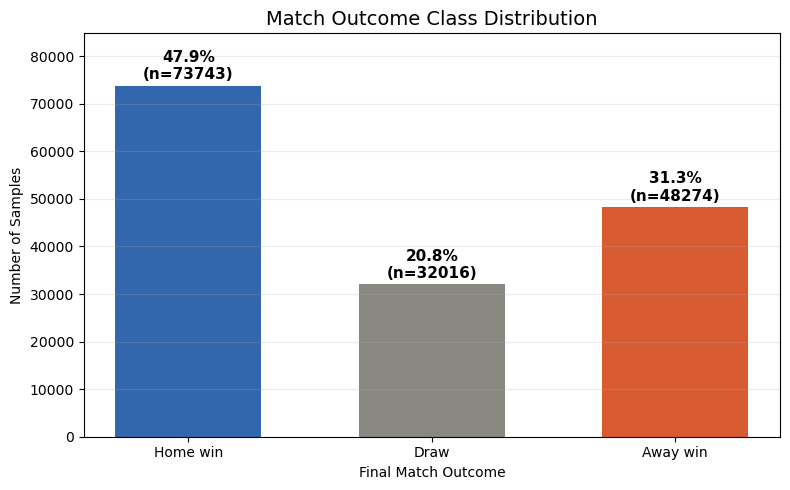

In [50]:
counts = possession_features["final_outcome"].value_counts().sort_index()
counts = counts.reindex([0, 1, 2], fill_value=0)

labels = ["Home win", "Draw", "Away win"]
colors = ["#3266ad", "#888780", "#D85A30"]

percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    labels,
    counts.values,
    color=colors,
    width=0.6
)

for bar, pct, count in zip(bars, percentages, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f"{pct:.1f}%\n(n={count})",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Match Outcome Class Distribution",
    fontsize=14
)

ax.set_ylabel("Number of Samples")
ax.set_xlabel("Final Match Outcome")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

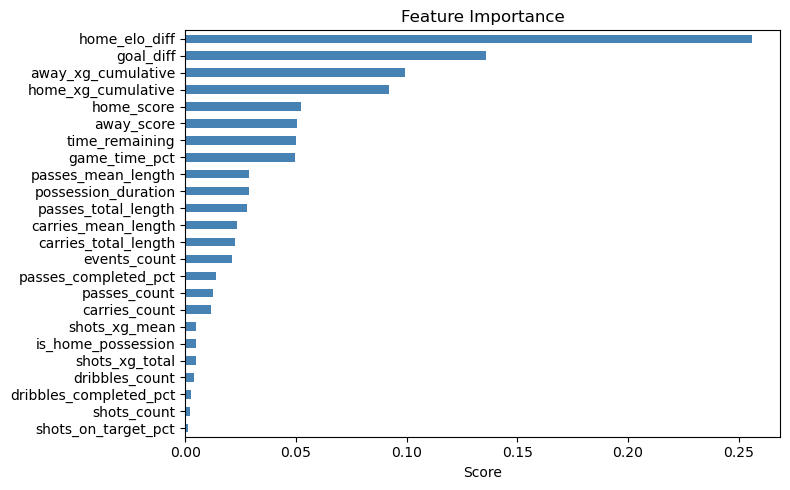

In [56]:
rf_fi = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_fi.fit(
    possession_features[numeric_cols].fillna(0),
    possession_features['final_outcome']
)

importances = pd.Series(
    rf_fi.feature_importances_,
    index=numeric_cols
).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='steelblue')

plt.title("Feature Importance")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

In [66]:
np.save('../data/processed/notebook_02/X_train_scaled.npy', X_train_scaled)
np.save('../data/processed/notebook_02/X_val_scaled.npy',   X_val_scaled)
np.save('../data/processed/notebook_02/X_test_scaled.npy',  X_test_scaled)
np.save('../data/processed/notebook_02/y_train.npy',        y_train)
np.save('../data/processed/notebook_02/y_val.npy',          y_val)
np.save('../data/processed/notebook_02/y_test.npy',         y_test)
np.save('../data/processed/notebook_02/mask_train.npy',     mask_train)
np.save('../data/processed/notebook_02/mask_val.npy',       mask_val)
np.save('../data/processed/notebook_02/mask_test.npy',      mask_test)
np.save('../data/processed/notebook_02/X_padded.npy',       X_padded)
np.save('../data/processed/notebook_02/y_padded.npy',       y_padded)
np.save('../data/processed/notebook_02/mask_padded.npy',    mask_padded)
# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

# Save train/val/test split IDs
split_ids = {
    'train': train_ids,
    'val':   val_ids,
    'test':  test_ids
}
with open('../data/split_ids.pkl', 'wb') as f:
    pickle.dump(split_ids, f)

possession_features.to_pickle('../data/processed/possession_features.pkl')
print("Saved possession_features.pkl")

print("All files saved successfully.")

Saved possession_features.pkl
All files saved successfully.
